## config

In [ ]:
import pandas as pd
import re
import spacy
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize
import numpy as np
import pickle

#eda part
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/shakespeare_project/"

## Load the preprocessed corpus

In [ ]:
df = pd.read_pickle(BASE_PATH + "preprocessed_corpus_final.pkl")
print(f"Loaded {len(df)} works")
df[["filename", "author", "label", "n_words"]]

Loaded 62 works


,filename,author,label,n_words
0,a_midsummer_night_s_dream.txt,shakespeare,1.0,17157
1,all_s_well_that_ends_well.txt,shakespeare,1.0,24487
2,as_you_like_it.txt,shakespeare,1.0,22993
3,cymbeline.txt,shakespeare,1.0,28854
4,king_henry_the_eighth.txt,shakespeare,1.0,25772
...,...,...,...,...
57,henry_vi_part1.txt,henry_vi_part1,NaN,21271
58,henry_vi_part2.txt,henry_vi_part2,NaN,24833
59,henry_vi_part3.txt,henry_vi_part3,NaN,23971
60,spanish_tragedy.txt,spanish_tragedy,NaN,21907


## Clean and normalize text before chunking

Remove:
* Footnotes and trailing glossary sections.
* Editorial annotations and formatting artifacts.
* Stage directions, act/scene headings, and speaker labels.
* Named entities (e.g., people and locations) identified using spaCy.
* Known character and protagonist names using a rule-based safety-net replacement.
* Formatting inconsistencies through punctuation and whitespace normalization.

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "lemmatizer", "attribute_ruler"])

ENTITY_LABELS = {"PERSON", "GPE", "NORP", "FAC", "LOC"}

KNOWN_NAMES_SAFETY_NET = [
    "faustus", "tamburlaine", "theridamas", "erastus", "perseda", "basilisco", "piston",
    "bel", "horatio", "cokes", "waspe", "face", "matheo", "thorello", "mammon", "subtle",
    "quarlous", "cob", "clement", "hector", "antony", "caesar", "warwick", "edward",
    "cardinal", "page", "gaveston",
]
ADDITIONAL_LEAKS = ["leath", "mus", "mam", "vo", "sub", "quar", "mat", "clem", "lor", "whit", "ju", "lit"]

KNOWN_NAMES_SAFETY_NET.extend(ADDITIONAL_LEAKS)
SAFETY_NET_SET = set(KNOWN_NAMES_SAFETY_NET)


def strip_gutenberg_paras(paras):
    return [p for p in paras if "gutenberg" not in p.lower()]


def strip_footnote_paras(paras):
    pat = re.compile(r"^(\[\d+\]|l\.\s?\d+\.|p\.\s?\d+,)", re.I)
    return [p for p in paras if not pat.match(p.strip())]

gloss_pat = re.compile(r"^[a-z][a-z'-]{1,20},\s[^?!]{2,80}\.$")

def is_glossary_entry(p):
    p = p.strip()
    if "\n" in p or len(p.split()) > 15:
        return False
    return bool(gloss_pat.match(p))

def strip_trailing_glossary(paras, window=30, density_thresh=0.6):
    flags = [is_glossary_entry(p) for p in paras]
    n = len(paras)
    if n < window:
        return paras
    if sum(flags[:n // 2]) / max(1, n // 2) > 0.15:
        return paras
    for i in range(n - window, -1, -1):
        if sum(flags[i:i + window]) / window < density_thresh:
            return paras[:i + window]
    return paras

def clean_play_pre_ner(text):
    paras = text.split("\n\n")
    paras = strip_gutenberg_paras(paras)
    paras = strip_footnote_paras(paras)
    paras = strip_trailing_glossary(paras)
    text = "\n\n".join(paras)

    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u00b4", "'").replace("`", "'")
    text = text.replace("\u2014", "--").replace("\u2013", "--")
    text = text.replace("\u2015", "--").replace("\u2212", "--")

    text = re.sub(r"\[[^\[\]\n]{0,200}\]", "", text)
    text = re.sub(r"\([^()\n]{0,200}\)", "", text)
    text = re.sub(r"_[^_\n]{0,200}_", "", text)
    text = re.sub(r"^[A-Z][A-Z\s,\.]{2,}\.$", "", text, flags=re.MULTILINE)

    LABEL_UNIT = r"[A-Z][a-z]{0,5}(?:\s+[A-Z][a-z]{0,5})?\s*\."
    text = re.sub(rf"^[ \t]*(?:{LABEL_UNIT}\s*){{1,3}}", "", text, flags=re.MULTILINE)

    text = re.sub(
        r"^\s*(enter|exit|exeunt|manet|re-enter)\b[^\n]*$",
        "", text, flags=re.IGNORECASE | re.MULTILINE
    )
    text = re.sub(r"^\s*(ACT|SCENE)\b[^\n]*$", "", text, flags=re.IGNORECASE | re.MULTILINE)

    text = text.replace("_", "").replace("[", "").replace("]", "")
    text = re.sub(r"\(\s*\)", "", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"[ \t]+([,;:.!?])", r"\1", text)
    return text.strip()

def build_masked_and_display(doc):
    masked_tokens, display_tokens = [], []

    for tok in doc:
        ws = tok.whitespace_
        tok_text = tok.text
        tok_lower = tok_text.lower()

        if tok.ent_type_ in ENTITY_LABELS:
            masked_tokens.append("_name_" + ws)
            display_tokens.append("_name_" + ws)
            continue

        clean_lookup = re.sub(r'[^a-zA-Z0-9]', '', tok_lower)

        if clean_lookup in SAFETY_NET_SET and len(clean_lookup) > 0:
            masked_text = tok_lower.replace(clean_lookup, "_name_")
            masked_tokens.append(masked_text + ws)
            display_tokens.append(masked_text + ws)
        else:
            masked_tokens.append(tok_lower + ws)
            display_tokens.append(tok_lower + ws)

    return "".join(masked_tokens), "".join(display_tokens)

def finalize_text(text):
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

_before_words = df["text"].apply(lambda t: len(t.split()))
pre_ner_text = df["text"].apply(clean_play_pre_ner)
docs = nlp.pipe(pre_ner_text.tolist(), batch_size=8)
masked_display_pairs = [build_masked_and_display(doc) for doc in docs]
masked_text = [pair[0] for pair in masked_display_pairs]
raw_display_text = [pair[1] for pair in masked_display_pairs]

df["text"] = [finalize_text(t) for t in masked_text]
df["display_text"] = [finalize_text(t) for t in raw_display_text]

df["n_words"] = df["text"].apply(lambda t: len(t.split()))
df["n_display_words"] = df["display_text"].apply(lambda t: len(t.split()))
mismatch = df["n_display_words"] != df["n_words"]

print(f"Word-count mismatches (should be 0): {mismatch.sum()}")
if mismatch.any():
    print(df.loc[mismatch, "filename"].tolist())

print("\nResidual protagonist-name check, whole-word only (should all be 0):")
for name in KNOWN_NAMES_SAFETY_NET:
    count = df["text"].str.contains(rf"\b{name}\b", regex=True).sum()
    if count:
        print(f"  '{name}': present in {count} / {len(df)} texts")

_report = df[["filename", "author"]].copy()
_report["words_removed"] = _before_words - df["n_words"]
_report["pct_removed"] = (_report["words_removed"] / _before_words).round(3)
print(f"\nTotal words removed: {_report['words_removed'].sum()} of {_before_words.sum()}")

df.to_pickle(BASE_PATH + "preprocessed_corpus_cleaned_v2.pkl")
print("Saved preprocessed_corpus_cleaned_v2.pkl")

Word-count mismatches (should be 0): 0

Residual protagonist-name check, whole-word only (should all be 0):
  'face': present in 1 / 62 texts
  'subtle': present in 1 / 62 texts
  'antony': present in 1 / 62 texts
  'caesar': present in 1 / 62 texts
  'edward': present in 1 / 62 texts
  'page': present in 1 / 62 texts
  'whit': present in 2 / 62 texts

Total words removed: 96161 of 1394976
Saved preprocessed_corpus_cleaned_v2.pkl


Note: Residual protagonist-name counts of 1 (and 2 for whit) are considered acceptable. These isolated occurrences are negligible relative to the 62-text corpus and typically result from legitimate contextual usage or unavoidable word ambiguity rather than incomplete preprocessing. Consequently, they are not expected to have a meaningful impact on the stylometric attribution analysis.

In [ ]:
residual_checks = {
    "underscore_markup": df["text"].apply(lambda t: bool(re.search(r"_(?!name_)[^_\n]{1,200}_", t))),
    "brackets": df["text"].str.contains(r"\[", regex=True, na=False),
    "dramatis_personae_heading": df["text"].str.contains(
        r"dramatis\s+person|persons\s+represented", case=False, regex=True, na=False
    ),
    "act_scene_header": df["text"].str.contains(
        r"(?m)^\s*(?:act|scene)\s+[ivx0-9]", case=False, regex=True, na=False
    ),
    "gutenberg_mention": df["text"].str.contains("gutenberg", case=False, na=False),
    "unnormalized_dash": df["text"].str.contains(
        "[\u2014\u2013\u2015\u2212]", regex=True, na=False
    ),
    "space_before_punct": df["text"].str.contains(
        r"[ \t][,;:.!?]", regex=True, na=False
    ),
}

print("Residual markup check (should all be 0):")
for name, mask in residual_checks.items():
    n = mask.sum()
    print(f"  {name}: {n} works" + (f" -> {df.loc[mask, 'filename'].tolist()}" if n else ""))

true_corruption_counts = df["text"].apply(lambda t: len(re.findall(r"(?<![a-z'])(?![iao]\b)[a-z](?![a-z'])", t)))
print("\nTrue standalone single-letter anomalies (excluding i, a, o), top 15:")
print(df[["filename", "author"]].assign(anomalies=true_corruption_counts)
      .sort_values("anomalies", ascending=False).head(15).to_string(index=False))

Residual markup check (should all be 0):
  underscore_markup: 62 works -> ['a_midsummer_night_s_dream.txt', 'all_s_well_that_ends_well.txt', 'as_you_like_it.txt', 'cymbeline.txt', 'king_henry_the_eighth.txt', 'king_richard_the_third.txt', 'love_s_labour_s_lost.txt', 'measure_for_measure.txt', 'much_ado_about_nothing.txt', 'pericles_prince_of_tyre.txt', 'the_comedy_of_errors.txt', 'the_first_part_of_king_henry_the_fourth.txt', 'the_life_and_death_of_king_john.txt', 'the_life_and_death_of_king_richard_the_second.txt', 'the_life_of_king_henry_the_fifth.txt', 'the_life_of_timon_of_athens.txt', 'the_merchant_of_venice.txt', 'the_merry_wives_of_windsor.txt', 'the_second_part_of_king_henry_the_fourth.txt', 'the_taming_of_the_shrew.txt', 'the_tempest.txt', 'the_tragedy_of_antony_and_cleopatra.txt', 'the_tragedy_of_coriolanus.txt', 'the_tragedy_of_hamlet_prince_of_denmark.txt', 'the_tragedy_of_julius_caesar.txt', 'the_tragedy_of_king_lear.txt', 'the_tragedy_of_macbeth.txt', 'the_tragedy_of_othe

In [ ]:
play_word_counts = {}
for _, row in df.iterrows():
    words = re.findall(r"[a-z']+", row["text"])
    play_word_counts[row["filename"]] = Counter(words)

# Total count per word, across the whole corpus
total_counts = Counter()
for c in play_word_counts.values():
    total_counts.update(c)

# Only check words common enough to matter as features
candidates = [w for w, total in total_counts.items() if total >= 100]

rows = []
for w in candidates:
    per_play = {play: c[w] for play, c in play_word_counts.items() if c[w] > 0}
    total = sum(per_play.values())
    top_play, top_count = max(per_play.items(), key=lambda kv: kv[1])
    concentration = top_count / total
    n_plays = len(per_play)
    rows.append((w, total, top_play, concentration, n_plays))

leak_report = pd.DataFrame(rows, columns=["word", "total_count", "top_play", "concentration", "n_plays"])
leak_report = leak_report.sort_values("concentration", ascending=False)
print("Top 40 suspiciously concentrated words (likely names or play-specific vocabulary):")
print(leak_report.head(40).to_string(index=False))

Top 40 suspiciously concentrated words (likely names or play-specific vocabulary):
    word  total_count                                top_play  concentration  n_plays
      vo          202                marlowe_tamburlaine1.txt       0.995050        2
     sum          169              nashe_summer_testament.txt       0.568047       30
   knock          167             jonson_bartholomew_fair.txt       0.502994       34
      oh          235                    jonson_every_man.txt       0.502128       17
       c          139                        kyd_cornelia.txt       0.496403       25
       e          109                marlowe_tamburlaine1.txt       0.486239        7
    step          220                    jonson_every_man.txt       0.450000       38
    i'le          237 fletcher_the_tragedy_of_valentinian.txt       0.413502        4
   chain          109                the_comedy_of_errors.txt       0.412844       21
   henry          147                      henry_vi_part3

## Chunk each play into fixed-size windows

Every chunk keeps a reference back to its source play (`play`), its author, and its label.


In [ ]:
CHUNK_SIZE = 1000
MIN_CHUNK_FRACTION = 0.5
def chunk_text(text, chunk_size=CHUNK_SIZE, min_fraction=MIN_CHUNK_FRACTION):
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk_words = words[i:i + chunk_size]
        if len(chunk_words) < chunk_size * min_fraction:
            continue  # drop a too-short trailing chunk
        chunks.append(" ".join(chunk_words))
    return chunks

rows = []
for _, row in df.iterrows():
    chunks = chunk_text(row["text"])
    display_words = row["display_text"].split()
    for i, chunk in enumerate(chunks):
        start = i * CHUNK_SIZE
        display_chunk = " ".join(display_words[start:start + CHUNK_SIZE])
        rows.append({
            "chunk_id": f"{row['filename']}_{i}",
            "play": row["filename"],
            "author": row["author"],
            "label": row["label"],
            "text": chunk,
            "n_words": len(chunk.split()),
            "display_text": display_chunk,
        })

chunked_df = pd.DataFrame(rows)
print(f"Created {len(chunked_df)} chunks from {len(df)} works")
chunked_df.head()

Created 1297 chunks from 62 works


,chunk_id,play,author,label,text,n_words,display_text
0,a_midsummer_night_s_dream.txt_0,a_midsummer_night_s_dream.txt,shakespeare,1.0,a midsummer night's dream contents a room in _...,1000,a midsummer night's dream contents a room in _...
1,a_midsummer_night_s_dream.txt_1,a_midsummer_night_s_dream.txt,shakespeare,1.0,my eyes. ay me! for aught that i could ever re...,1000,my eyes. ay me! for aught that i could ever re...
2,a_midsummer_night_s_dream.txt_2,a_midsummer_night_s_dream.txt,shakespeare,1.0,"the actors; and so grow to a point. _name_, ou...",1000,"the actors; and so grow to a point. _name_, ou..."
3,a_midsummer_night_s_dream.txt_3,a_midsummer_night_s_dream.txt,shakespeare,1.0,"of the night. i jest to _name_, and make him s...",1000,"of the night. i jest to _name_, and make him s..."
4,a_midsummer_night_s_dream.txt_4,a_midsummer_night_s_dream.txt,shakespeare,1.0,"in forty minutes. having once this juice, i'll...",1000,"in forty minutes. having once this juice, i'll..."


In [ ]:
summary = chunked_df.groupby(["label", "author"], dropna=False)["chunk_id"].count().sort_values(ascending=False)
print(summary)

print()
totals = chunked_df.groupby("label", dropna=False)["chunk_id"].count()
print("Positive (Shakespeare) chunks:  ", totals.get(1.0, 0))
print("Negative (contemporary) chunks: ", totals.get(0.0, 0))
print("Disputed chunks:                ", totals[totals.index.isna()].sum())

if totals.get(0.0, 0) > 0:
    ratio = totals.get(1.0, 0) / totals.get(0.0, 0)
    print(f"\nClass balance ratio (chunk-level): {ratio:.2f}x")

print("\nChunk word count stats:")
print(chunked_df["n_words"].describe())

label  author          
1.0    shakespeare         723
0.0    jonson              115
       marlowe             102
       fletcher             84
       massinger            51
       greene               46
       kyd                  33
NaN    henry_vi_part3       24
       henry_vi_part2       24
       spanish_tragedy      22
       henry_vi_part1       21
0.0    nashe                17
NaN    double_falsehood     15
Name: chunk_id, dtype: int64

Positive (Shakespeare) chunks:   723
Negative (contemporary) chunks:  448
Disputed chunks:                 106

Class balance ratio (chunk-level): 1.61x

Chunk word count stats:
count    1277.000000
mean      994.684417
std        41.749006
min       513.000000
25%      1000.000000
50%      1000.000000
75%      1000.000000
max      1000.000000
Name: n_words, dtype: float64


In [ ]:
chunked_df.to_pickle(BASE_PATH + "chunked_corpus.pkl")
print("Saved chunked_corpus.pkl —", len(chunked_df), "chunks")
print("\nUnique plays represented:", chunked_df["play"].nunique())
#Any train/test split downstream must split by `play`, not by random chunk

## train/test split, by whole play


In [ ]:
# train/test split, by whole play, stratified per autor
labeled_df = chunked_df[chunked_df["label"].notna()].copy()
disputed_df = chunked_df[chunked_df["label"].isna()].copy()

play_info = labeled_df.groupby("play").agg(
    label=("label", "first"),
    author=("author", "first")
).reset_index()

print("Plays per author:")
print(play_info.groupby("author").size().sort_values())

train_plays, test_plays = [], []

for author, group in play_info.groupby("author"):
    plays = group["play"].tolist()
    n = len(plays)

    if n == 1:
        # only one play from this author -- it must go to train,
        # or the model never sees this author at all
        train_plays.extend(plays)
        continue

    n_test = max(1, round(n * 0.2))
    n_test = min(n_test, n - 1)  # never send every play from an author to test

    a_train, a_test = train_test_split(plays, test_size=n_test, random_state=42)
    train_plays.extend(a_train)
    test_plays.extend(a_test)

train_df = labeled_df[labeled_df["play"].isin(train_plays)].reset_index(drop=True)
test_df = labeled_df[labeled_df["play"].isin(test_plays)].reset_index(drop=True)

print(f"\nTrain: {len(train_df)} chunks from {train_df['play'].nunique()} plays")
print(f"Test:  {len(test_df)} chunks from {test_df['play'].nunique()} plays")
print(f"Disputed: {len(disputed_df)} chunks (held out, no label)")

print("\nTrain label balance:")
print(train_df["label"].value_counts())
print("\nTest label balance:")
print(test_df["label"].value_counts())

print("\nTrain author balance:")
print(train_df.groupby("author")["chunk_id"].count())
print("\nTest author balance:")
print(test_df.groupby("author")["chunk_id"].count())

overlap = set(train_df["play"]) & set(test_df["play"])
print(f"\nPlays in both train and test (should be 0): {len(overlap)}")

Plays per author:
author
nashe           1
kyd             2
massinger       3
greene          3
jonson          4
fletcher        4
marlowe         6
shakespeare    33
dtype: int64

Train: 907 chunks from 43 plays
Test:  264 chunks from 13 plays
Disputed: 106 chunks (held out, no label)

Train label balance:
label
1.0    584
0.0    323
Name: count, dtype: int64

Test label balance:
label
1.0    139
0.0    125
Name: count, dtype: int64

Train author balance:
author
fletcher        68
greene          30
jonson          78
kyd             15
marlowe         81
massinger       34
nashe           17
shakespeare    584
Name: chunk_id, dtype: int64

Test author balance:
author
fletcher        16
greene          16
jonson          37
kyd             18
marlowe         21
massinger       17
shakespeare    139
Name: chunk_id, dtype: int64

Plays in both train and test (should be 0): 0


## Feature extraction

### Function-word frequencies

Function words (articles, prepositions, pronouns, conjunctions, auxiliary verbs) are the
classic stylometric signal — they capture unconscious style rather than topic, since every
author uses "the," "of," "and," etc. at their own characteristic rate regardless of subject
matter.

The vectorizer is fit only on the training set, test and disputed chunks are only
*transformed*, never used to define the feature space.

In [ ]:
FUNCTION_WORDS = [
    "a", "an", "the", "and", "but", "or", "nor", "for", "so", "yet",
    "of", "to", "in", "on", "at", "by", "with", "from", "into", "onto",
    "over", "under", "through", "between", "among", "about", "against",
    "before", "after", "during", "since", "until", "while", "though",
    "although", "because", "if", "unless", "as", "than", "that", "which",
    "who", "whom", "whose", "what", "when", "where", "why", "how",
    "i", "me", "my", "mine", "we", "us", "our", "ours",
    "you", "your", "yours", "he", "him", "his", "she", "her", "hers",
    "it", "its", "they", "them", "their", "theirs",
    "this", "that", "these", "those",
    "is", "am", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "do", "does", "did",
    "will", "would", "shall", "should", "can", "could", "may", "might", "must",
    "not", "no", "none", "any", "some", "all", "each", "every", "both",
    "either", "neither", "one", "other", "another", "such", "same",
    "very", "too", "so", "just", "only", "even", "still", "yet", "again",
]
FUNCTION_WORDS = sorted(set(FUNCTION_WORDS))
print(f"Using {len(FUNCTION_WORDS)} function words")

func_vectorizer = CountVectorizer(vocabulary=FUNCTION_WORDS, lowercase=True, token_pattern=r"\b\w+\b")
func_vectorizer.fit(train_df["text"])

# Extract raw counts
X_train_func_raw = func_vectorizer.transform(train_df["text"])
X_test_func_raw = func_vectorizer.transform(test_df["text"])
X_disputed_func_raw = func_vectorizer.transform(disputed_df["text"])

# Normalize to relative frequencies via L1 norm
X_train_func = normalize(X_train_func_raw, norm='l1', axis=1).toarray()
X_test_func = normalize(X_test_func_raw, norm='l1', axis=1).toarray()
X_disputed_func = normalize(X_disputed_func_raw, norm='l1', axis=1).toarray()

y_train = train_df["label"].values
y_test = test_df["label"].values

print("\nFeature matrix production successful!")
print("Function-word feature matrix shape (train):   ", X_train_func.shape)
print("Function-word feature matrix shape (test):    ", X_test_func.shape)
print("Function-word feature matrix shape (disputed):", X_disputed_func.shape)

Using 122 function words

Feature matrix production successful!
Function-word feature matrix shape (train):    (907, 122)
Function-word feature matrix shape (test):     (264, 122)
Function-word feature matrix shape (disputed): (106, 122)


### Character n-grams

In [ ]:
char_vectorizer = CountVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 4),
    max_features=2000,
    lowercase=True
)
char_vectorizer.fit(train_df["text"])
X_train_char_raw = char_vectorizer.transform(train_df["text"])
X_test_char_raw = char_vectorizer.transform(test_df["text"])
X_disputed_char_raw = char_vectorizer.transform(disputed_df["text"])
# This divides each row by its total character n-gram count, calculating a true
# relative frequency profile for the sub-word markers.
X_train_char = normalize(X_train_char_raw, norm='l1', axis=1).toarray()
X_test_char = normalize(X_test_char_raw, norm='l1', axis=1).toarray()
X_disputed_char = normalize(X_disputed_char_raw, norm='l1', axis=1).toarray()

print(f"Character n-gram feature matrix construction successful!")
print("Character n-gram feature matrix shape (train):   ", X_train_char.shape)
print("Character n-gram feature matrix shape (test):    ", X_test_char.shape)
print("Character n-gram feature matrix shape (disputed):", X_disputed_char.shape)

Character n-gram feature matrix construction successful!
Character n-gram feature matrix shape (train):    (907, 2000)
Character n-gram feature matrix shape (test):     (264, 2000)
Character n-gram feature matrix shape (disputed): (106, 2000)


## Burrows' Zeta: distinctive marker words

Function-word frequency and character n-grams both measure *how often* something occurs.
Zeta looks at which words does one class use in almost
every chunk, that the other class almost never uses at all - regardless of how many
times it's repeated when it does appear. A word used once per chunk in 95% of Shakespeare
chunks and in 2% of contemporary chunks is a strong marker even if its raw frequency count
is unremarkable.

**Word selection happens on `train_df` only** - the candidate vocabulary and the
resulting marker-word list are both derived purely from training data, so no information
from `test_df` or `disputed_df` leaks into which words get chosen.

In [ ]:
# Candidate vocabulary: moderately frequent content words, excluding the function words
# already captured by func_vectorizer (no point re-measuring the same signal two ways).
candidate_vectorizer = CountVectorizer(
    lowercase=True,
    max_features=3000,
    min_df=3,
    stop_words=None,
)
candidate_vectorizer.fit(train_df["text"])
candidate_words = [w for w in candidate_vectorizer.get_feature_names_out() if w not in FUNCTION_WORDS]

print(f"Candidate vocabulary: {len(candidate_words)} words (after removing function words)")

Candidate vocabulary: 2882 words (after removing function words)


In [ ]:
# Presence (not frequency) of each candidate word per training chunk
presence_vectorizer = CountVectorizer(vocabulary=candidate_words, lowercase=True, binary=True)
X_presence_train = presence_vectorizer.transform(train_df["text"]).toarray()

is_shakespeare = (train_df["label"].values == 1)
is_contemporary = (train_df["label"].values == 0)

# DP_A / DP_B = proportion of chunks in each class containing the word at least once
DP_shakespeare = X_presence_train[is_shakespeare].mean(axis=0)
DP_contemporary = X_presence_train[is_contemporary].mean(axis=0)

# Burrows' Zeta, standard 0-2 scale: 2 = word is in every Shakespeare chunk and no
# contemporary chunk; 0 = the reverse; 1 = no discriminating power either way.
zeta_scores = DP_shakespeare + (1 - DP_contemporary)

zeta_df = pd.DataFrame({
    "word": candidate_words,
    "DP_shakespeare": DP_shakespeare,
    "DP_contemporary": DP_contemporary,
    "zeta": zeta_scores,
}).sort_values("zeta", ascending=False)

print("Top 15 Shakespeare marker words (highest Zeta):")
print(zeta_df.head(15).to_string(index=False))

print("\nTop 15 contemporary marker words (lowest Zeta):")
print(zeta_df.tail(15).to_string(index=False))

Top 15 Shakespeare marker words (highest Zeta):
     word  DP_shakespeare  DP_contemporary     zeta
     hath        0.828767         0.578947 1.249820
     doth        0.551370         0.303406 1.247964
   tongue        0.349315         0.117647 1.231668
       th        0.496575         0.266254 1.230321
    comes        0.496575         0.287926 1.208650
     show        0.385274         0.179567 1.205707
     most        0.686644         0.482972 1.203672
   gentle        0.347603         0.151703 1.195900
       ay        0.482877         0.294118 1.188759
therefore        0.467466         0.281734 1.185732
   answer        0.339041         0.154799 1.184242
       go        0.813356         0.631579 1.181777
    speak        0.693493         0.520124 1.173369
     lord        0.717466         0.544892 1.172574
     dost        0.344178         0.173375 1.170803

Top 15 contemporary marker words (lowest Zeta):
  word  DP_shakespeare  DP_contemporary     zeta
    em        0.118151

### Check suspect Zeta words for edition/spelling artifacts

`"th"`, `"em"`, and `"le"` look like elision/contraction fragments (`th'other`, `'em`,
`I'le`) rather than ordinary words - possibly real elision-habit signal, but worth
confirming they're not a tokenization quirk. `"shew"` (contemporary marker) vs
`"show"` (Shakespeare marker): same word, two spellings, split
cleanly across classes. Real style
should be spread across every play by a class

In [ ]:
suspect_words = ["th", "em", "le", "shew", "show"]

for word in suspect_words:
    pattern = re.compile(rf"\b{re.escape(word)}\b", flags=re.IGNORECASE)
    train_df[f"_has_{word}"] = train_df["text"].str.contains(pattern)

    sh_rate = train_df.loc[train_df["label"] == 1, f"_has_{word}"].mean()
    co_rate = train_df.loc[train_df["label"] == 0, f"_has_{word}"].mean()
    print(f"'{word}': Shakespeare {sh_rate:.1%} of chunks  |  Contemporary {co_rate:.1%} of chunks")

    print(f"  Per-play rate (Shakespeare):")
    print("   ", train_df[train_df["label"] == 1].groupby("play")[f"_has_{word}"].mean()
          .sort_values(ascending=False).head(5).to_string().replace("\n", "\n    "))
    print(f"  Per-play rate (Contemporary):")
    print("   ", train_df[train_df["label"] == 0].groupby("play")[f"_has_{word}"].mean()
          .sort_values(ascending=False).head(5).to_string().replace("\n", "\n    "))

    # one example snippet from each class, if present
    for label_val, label_name in [(1, "Shakespeare"), (0, "Contemporary")]:
        subset = train_df[(train_df["label"] == label_val) & (train_df[f"_has_{word}"])]
        if len(subset) > 0:
            sample_text = subset.iloc[0]["text"]
            match = pattern.search(sample_text)
            if match:
                start = max(0, match.start() - 30)
                print(f"  [{label_name}] ...{sample_text[start:match.end() + 30]}...")
    print()

train_df.drop(columns=[f"_has_{w}" for w in suspect_words], inplace=True)

'th': Shakespeare 49.7% of chunks  |  Contemporary 26.6% of chunks
  Per-play rate (Shakespeare):
    play
    the_tragedy_of_coriolanus.txt              1.000000
    the_tragedy_of_antony_and_cleopatra.txt    0.958333
    the_tempest.txt                            0.937500
    cymbeline.txt                              0.925926
    the_winter_s_tale.txt                      0.875000
  Per-play rate (Contemporary):
    play
    fletcher_beggars_bush.txt                  1.000000
    kyd_cornelia.txt                           0.800000
    fletcher_the_tragedy_of_valentinian.txt    0.636364
    fletcher_the_wild_goose_chase.txt          0.571429
    marlowe_tamburlaine1.txt                   0.409091
  [Shakespeare] ...ptune's yellow sands, marking th' embarkèd traders on the floo...
  [Contemporary] ... ports: good luck, and enter. th me, through so much hazard, o...

'em': Shakespeare 11.8% of chunks  |  Contemporary 25.4% of chunks
  Per-play rate (Shakespeare):
    play
    king_henr

In [ ]:
N_MARKERS = 30
EXCLUDED_WORDS = {"le", "shew", "show"}
zeta_df_filtered = zeta_df[~zeta_df["word"].isin(EXCLUDED_WORDS)]
marker_words = (
    zeta_df_filtered.head(N_MARKERS)["word"].tolist() +
    zeta_df_filtered.tail(N_MARKERS)["word"].tolist()
)
print(f"Using {len(marker_words)} total marker words ({N_MARKERS} per direction)")
zeta_vectorizer = CountVectorizer(vocabulary=marker_words, lowercase=True)

def zeta_features(df_subset):
    counts = zeta_vectorizer.transform(df_subset["text"]).toarray()
    lengths = df_subset["n_words"].values.reshape(-1, 1)
    return counts / lengths   # normalize by chunk length, same convention as func_vectorizer

X_train_zeta = zeta_features(train_df)
X_test_zeta = zeta_features(test_df)
X_disputed_zeta = zeta_features(disputed_df)

print(f"X_train_zeta: {X_train_zeta.shape}")

Using 60 total marker words (30 per direction)
X_train_zeta: (907, 60)


## Combine features and save everything for the modeling notebook

In [ ]:
X_train = np.hstack([X_train_func, X_train_char, X_train_zeta])
X_test = np.hstack([X_test_func, X_test_char, X_test_zeta])
X_disputed = np.hstack([X_disputed_func, X_disputed_char, X_disputed_zeta])

y_train = train_df["label"].values.astype(int)
y_test = test_df["label"].values.astype(int)

print("Final combined feature matrix shapes (function words + char n-grams + Zeta markers):")
print("  X_train:", X_train.shape, " y_train:", y_train.shape)
print("  X_test: ", X_test.shape, "  y_test: ", y_test.shape)
print("  X_disputed:", X_disputed.shape)

with open(BASE_PATH + "features.pkl", "wb") as f:
    pickle.dump({
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_test,
        "X_disputed": X_disputed,
        "train_df": train_df.drop(columns=["text"]),
        "test_df": test_df.drop(columns=["text"]),
        "disputed_df": disputed_df.drop(columns=["text"]),
        "function_words": FUNCTION_WORDS,
        "func_vectorizer": func_vectorizer,
        "char_vectorizer": char_vectorizer,
        "zeta_vectorizer": zeta_vectorizer,
        "marker_words": marker_words,
        "zeta_df": zeta_df,
    }, f)

print("\nSaved features.pkl to", BASE_PATH)

## Additional EDA

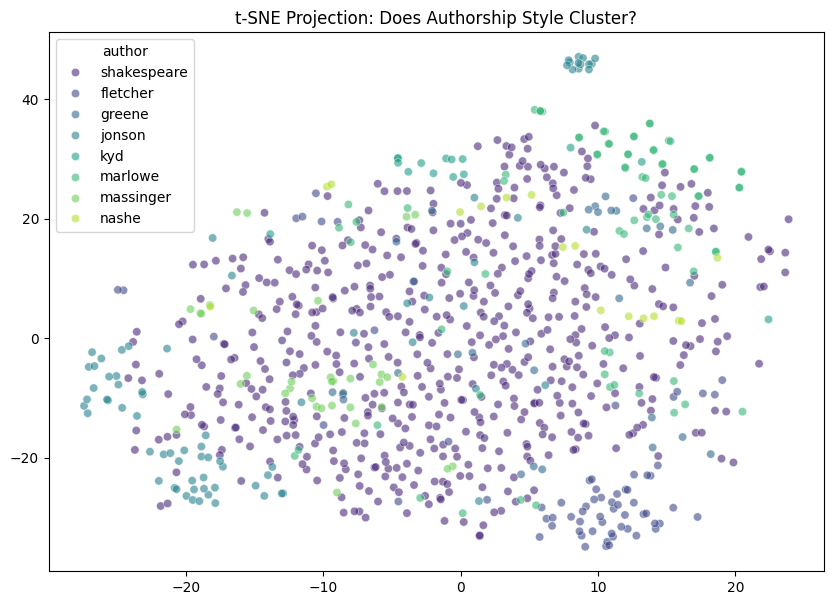

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_train)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_embedded[:, 0], y=X_embedded[:, 1],
    hue=train_df['author'], palette="viridis", alpha=0.6
)
plt.title("t-SNE Projection: Does Authorship Style Cluster?")
plt.show()

/tmp/ipykernel_4511/3140962201.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='importance', y='word', palette="magma")


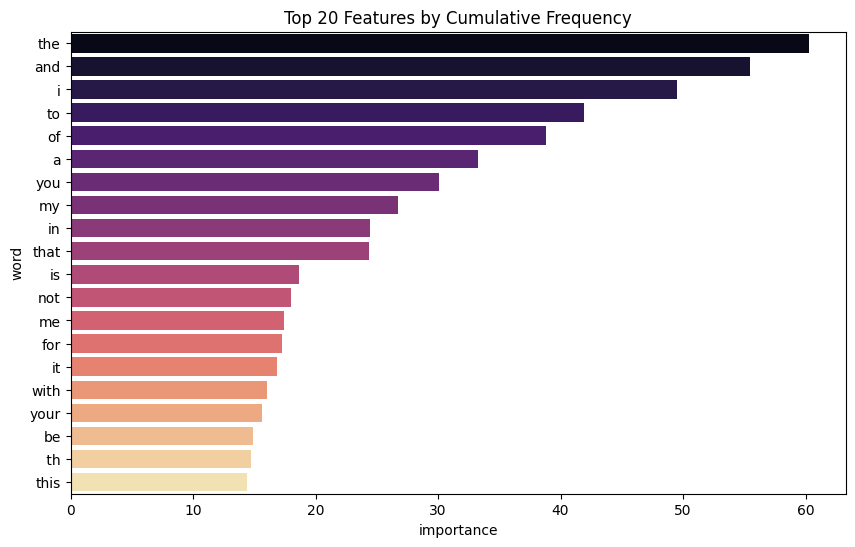

In [ ]:
feature_names = (
    list(FUNCTION_WORDS) +
    list(char_vectorizer.get_feature_names_out()) +
    list(marker_words)
)
# Sum importance across all training chunks
importance = np.sum(X_train, axis=0)
feat_imp = pd.DataFrame({'word': feature_names, 'importance': importance})
feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='word', palette="magma")
plt.title("Top 20 Features by Cumulative Frequency")
plt.show()

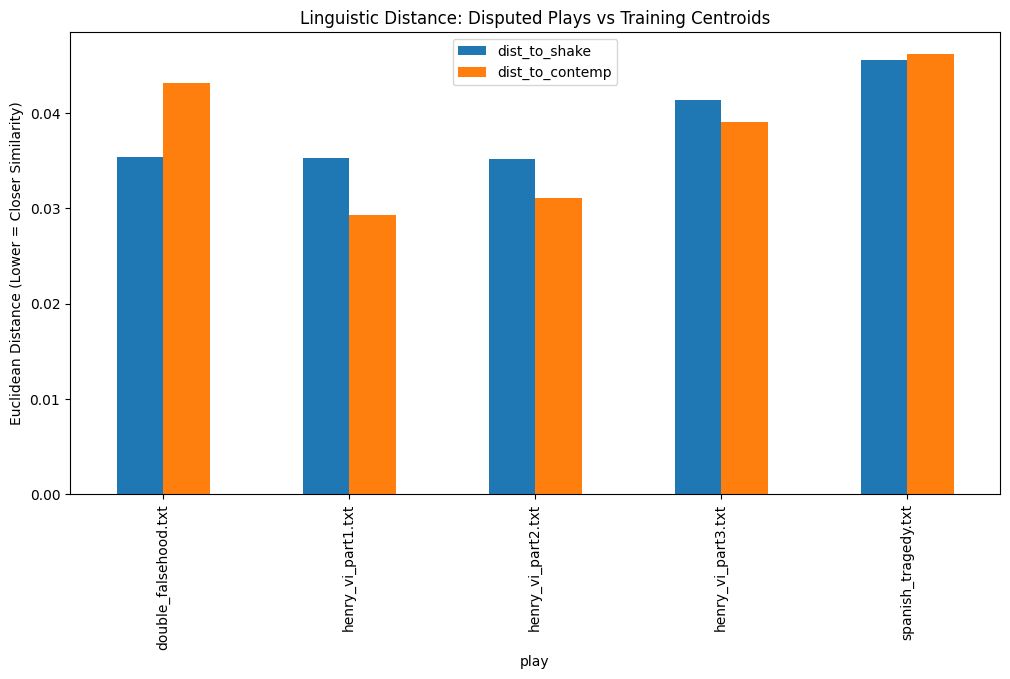

In [ ]:
# Calculate centroids
shakespeare_centroid = X_train[y_train == 1].mean(axis=0)
contemporary_centroid = X_train[y_train == 0].mean(axis=0)

# Calculate distances for each disputed play
results = []
for play in disputed_df['play'].unique():
    play_matrix = X_disputed[disputed_df['play'] == play]
    play_centroid = play_matrix.mean(axis=0)

    dist_shake = np.linalg.norm(play_centroid - shakespeare_centroid)
    dist_contemp = np.linalg.norm(play_centroid - contemporary_centroid)
    results.append({'play': play, 'dist_to_shake': dist_shake, 'dist_to_contemp': dist_contemp})

dist_df = pd.DataFrame(results)
dist_df.plot(x='play', y=['dist_to_shake', 'dist_to_contemp'], kind='bar', figsize=(12, 6))
plt.title("Linguistic Distance: Disputed Plays vs Training Centroids")
plt.ylabel("Euclidean Distance (Lower = Closer Similarity)")
plt.show()